# LLM answer correctness vs. rater agreement on citation support

Each reader-study question was independently rated by 3 raters. For every retrieved source a rater said whether it "Supports" the LLM answer; a rater **cites** the question if at least one of its sources supports (`any_source_supports`). We bin questions by how many of the 3 raters cited it (0/1/2/3) and plot the LLM's answer accuracy (`llm_is_correct`) per bin, with Wilson 95% CIs.

Restricted to the questions rated by exactly 3 raters so the 0..3 axis is well defined.

**LLM answerer:** Llama 4 via the Qwen agentic-retrieval pipeline with reranking (`results/results_llama4_qwenagent_reranked_rag.csv`).

**Caveat:** the reader study is *not* a random accuracy sample — the sampler drew 14 correct + 2 incorrect LLM answers per group (~87.5% correct by construction). Absolute bar heights reflect that quota; the *relationship* across agreement bins is the signal.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESP = "../results/reader_study/responses.csv"
OUT = "../plots/reader_study/citation_agreement_vs_accuracy.png"


def wilson(k, n, z=1.96):
    if n == 0:
        return (0.0, 0.0, 0.0)
    p = k / n
    denom = 1 + z * z / n
    centre = (p + z * z / (2 * n)) / denom
    half = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / denom
    return p, max(0.0, centre - half), min(1.0, centre + half)

In [2]:
# ---------- load & aggregate ----------
r = pd.read_csv(RESP)

# keep only questions rated by exactly 3 raters
n_raters = r.groupby("question_id")["pid"].nunique()
q3 = n_raters[n_raters == 3].index
sub = r[r.question_id.isin(q3)]

# per question: how many raters said >=1 source supports, and is LLM correct
agg = sub.groupby("question_id").agg(
    n_cite=("any_source_supports", "sum"),
    llm_correct=("llm_is_correct", "first"),
)

rows = []
for k in [0, 1, 2, 3]:
    g = agg[agg.n_cite == k]
    n = len(g)
    correct = int(g.llm_correct.sum())
    p, lo, hi = wilson(correct, n)
    rows.append((k, n, correct, p, lo, hi))
    print(f"{k} raters cite: n={n:3d}  LLM correct={correct:3d}  acc={p:.3f} "
          f"[{lo:.3f}, {hi:.3f}]")

ks = [x[0] for x in rows]
ns = [x[1] for x in rows]
ps = np.array([x[3] for x in rows])
los = np.array([x[4] for x in rows])
his = np.array([x[5] for x in rows])

0 raters cite: n= 13  LLM correct= 10  acc=0.769 [0.497, 0.918]
1 raters cite: n= 18  LLM correct= 12  acc=0.667 [0.437, 0.837]
2 raters cite: n= 26  LLM correct= 21  acc=0.808 [0.621, 0.915]
3 raters cite: n= 87  LLM correct= 83  acc=0.954 [0.888, 0.982]


saved ../plots/reader_study/citation_agreement_vs_accuracy.png


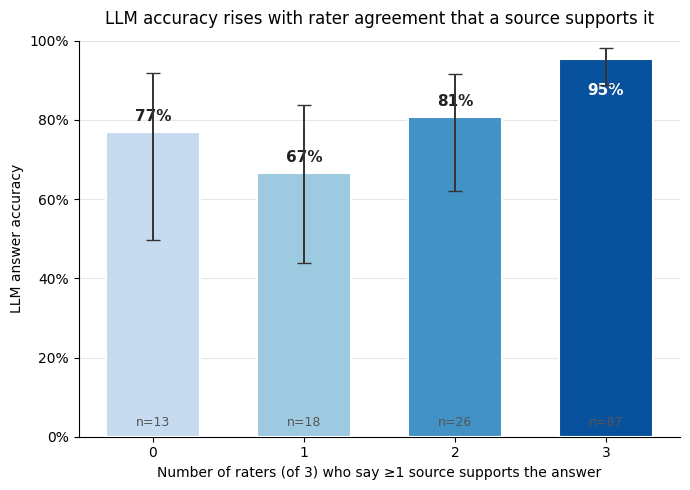

In [3]:
# ---------- plot ----------
# sequential single hue: darker = more raters agree support exists
hues = ["#c6dbef", "#9ecae1", "#4292c6", "#08519c"]

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(ks))
yerr = np.vstack([ps - los, his - ps])
bars = ax.bar(x, ps, width=0.62, color=hues, edgecolor="white", linewidth=1.5,
              zorder=3)
ax.errorbar(x, ps, yerr=yerr, fmt="none", ecolor="#333333", elinewidth=1.4,
            capsize=5, zorder=4)

for xi, p, n in zip(x, ps, ns):
    ax.text(xi, min(p + 0.02, 0.97) if p < 0.9 else p - 0.06,
            f"{p*100:.0f}%", ha="center",
            va="bottom" if p < 0.9 else "top",
            fontsize=11, fontweight="bold",
            color="white" if p >= 0.9 else "#222222")
    ax.text(xi, 0.02, f"n={n}", ha="center", va="bottom", fontsize=9,
            color="#555555")

ax.set_xticks(x)
ax.set_xticklabels([f"{k}" for k in ks])
ax.set_xlabel("Number of raters (of 3) who say \u22651 source supports the answer")
ax.set_ylabel("LLM answer accuracy")
ax.set_ylim(0, 1.0)
ax.set_yticks(np.arange(0, 1.01, 0.2))
ax.set_yticklabels([f"{int(t*100)}%" for t in np.arange(0, 1.01, 0.2)])
ax.set_title("LLM accuracy rises with rater agreement that a source supports it",
             fontsize=12, pad=12)
ax.spines[["top", "right"]].set_visible(False)
ax.yaxis.grid(True, color="#e6e6e6", zorder=0)
ax.set_axisbelow(True)

fig.tight_layout()
fig.savefig(OUT, dpi=200, bbox_inches="tight")
print("saved", OUT)
plt.show()